<a href="https://colab.research.google.com/github/Durgvanshi/Learning-Deep-Learning/blob/main/Vit_head_Imbalance_Phase0_Intuition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install timm -q

In [34]:
import timm
import timm
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

In [35]:
# Load pretrained ViT-B/16
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.eval()

print(model.default_cfg)  # shows expected input size, mean, std

{'url': '', 'hf_hub_id': 'timm/vit_base_patch16_224.augreg2_in21k_ft_in1k', 'architecture': 'vit_base_patch16_224', 'tag': 'augreg2_in21k_ft_in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'fixed_input_size': True, 'interpolation': 'bicubic', 'crop_pct': 0.9, 'crop_mode': 'center', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'num_classes': 1000, 'pool_size': None, 'first_conv': 'patch_embed.proj', 'classifier': 'head', 'license': 'apache-2.0'}


In [52]:
from torchvision import transforms
import requests
from PIL import Image # Added this import to resolve NameError
from io import BytesIO

imagePath = '/content/Cat_November_2010-1a.jpg'# upload any image here

img = Image.open(imagePath).convert('RGB')

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),                          # [0,255] → [0,1], shape becomes [3,224,224]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],     # shift to [-1, 1]
                         std=[0.5, 0.5, 0.5])
])

img_tensor = transform(img)          # shape: [3, 224, 224]
img_tensor = img_tensor.unsqueeze(0) # shape: [1, 3, 224, 224]  ← batch dimension

print(img_tensor.shape)

torch.Size([1, 3, 224, 224])


In [37]:
# Just print the last transformer block to understand its structure
print(model.blocks[-1])

Block(
  (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=768, out_features=2304, bias=True)
    (q_norm): Identity()
    (k_norm): Identity()
    (attn_drop): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (proj): Linear(in_features=768, out_features=768, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): Identity()
  (drop_path1): Identity()
  (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (act): GELU(approximate='none')
    (drop1): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
    (drop2): Dropout(p=0.0, inplace=False)
  )
  (ls2): Identity()
  (drop_path2): Identity()
)


In [38]:
# Storage for our attention weights
attention_store = {}

def hook_attention(module, input, output):
    # This fires after the attention module's forward pass
    # We need to recompute attention weights here because
    # timm does not expose them in the output

    B, N, C = input[0].shape          # batch, num_tokens, embed_dim

    # Recompute QKV exactly as timm does internally
    qkv = module.qkv(input[0])        # [B, N, 3*embed_dim]
    qkv = qkv.reshape(B, N, 3,
                      module.num_heads,
                      C // module.num_heads)
    qkv = qkv.permute(2, 0, 3, 1, 4) # [3, B, heads, N, head_dim]

    q, k, v = qkv.unbind(0)           # each: [B, heads, N, head_dim]

    # Attention scores
    scale = (C // module.num_heads) ** -0.5
    attn = (q @ k.transpose(-2, -1)) * scale   # [B, heads, N, N]
    attn = attn.softmax(dim=-1)                 # normalize across last dim

    attention_store['last_layer'] = attn.detach()  # save it

# Register the hook on the last block's attention module
hook = model.blocks[-1].attn.register_forward_hook(hook_attention)

print("Hook registered.")

Hook registered.


In [39]:
with torch.no_grad():               # no gradients needed — saves memory
    output = model(img_tensor)

# Verify the hook fired
attn_weights = attention_store['last_layer']
print(attn_weights.shape)           # expect [1, 12, 197, 197]

torch.Size([1, 12, 197, 197])


In [40]:
# Pick head 0 from the last layer
head_idx = 0

# CLS token is index 0, patches are index 1 onwards
cls_attn = attn_weights[0, head_idx, 0, 1:]   # shape: [196]

# Reshape to spatial grid
cls_attn_map = cls_attn.reshape(14, 14)        # shape: [14, 14]

# Convert to numpy for plotting
cls_attn_map = cls_attn_map.numpy()

print(f"Min attention: {cls_attn_map.min():.4f}")
print(f"Max attention: {cls_attn_map.max():.4f}")
print(f"Sum: {cls_attn_map.sum():.4f}")        # should be close to 1.0 — why?

Min attention: 0.0001
Max attention: 0.0847
Sum: 0.9969


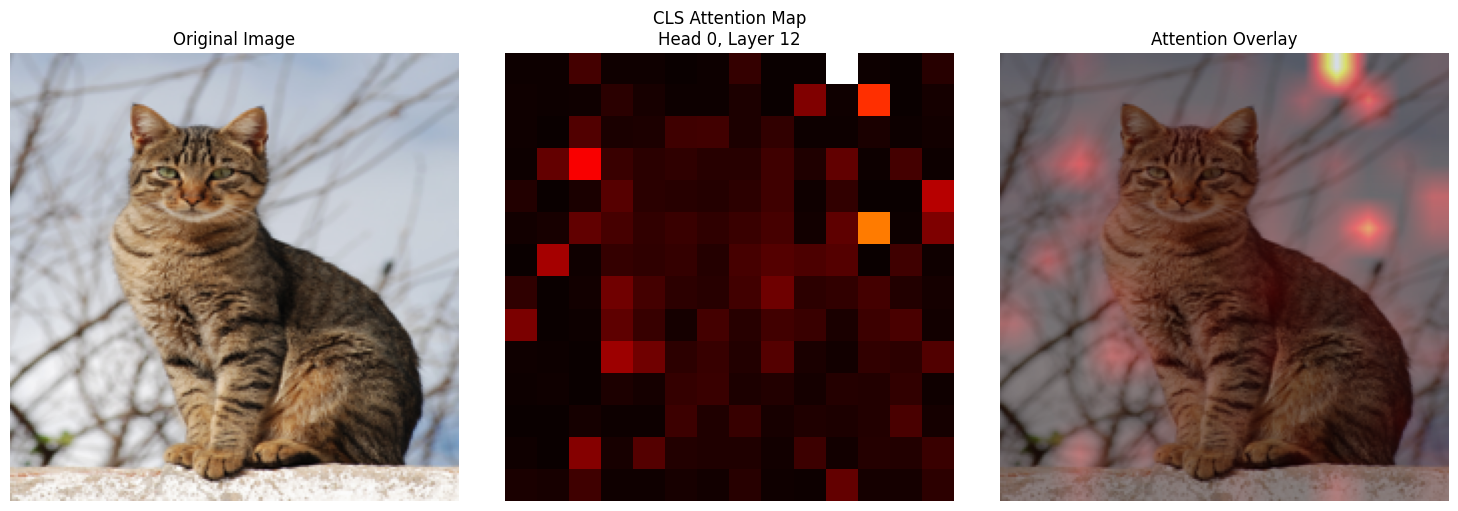

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Resize attention map from 14x14 to 224x224
attn_resized = np.array(
    Image.fromarray(cls_attn_map).resize((224, 224),
                                          resample=Image.BILINEAR)
)

# Convert original image to numpy for plotting
img_display = np.array(img.resize((224, 224)))

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(img_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Raw attention map
axes[1].imshow(cls_attn_map, cmap='hot')
axes[1].set_title(f'CLS Attention Map\nHead {head_idx}, Layer 12')
axes[1].axis('off')

# Overlay
axes[2].imshow(img_display)
axes[2].imshow(attn_resized, cmap='hot', alpha=0.5)
axes[2].set_title('Attention Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Clean up hook
hook.remove()

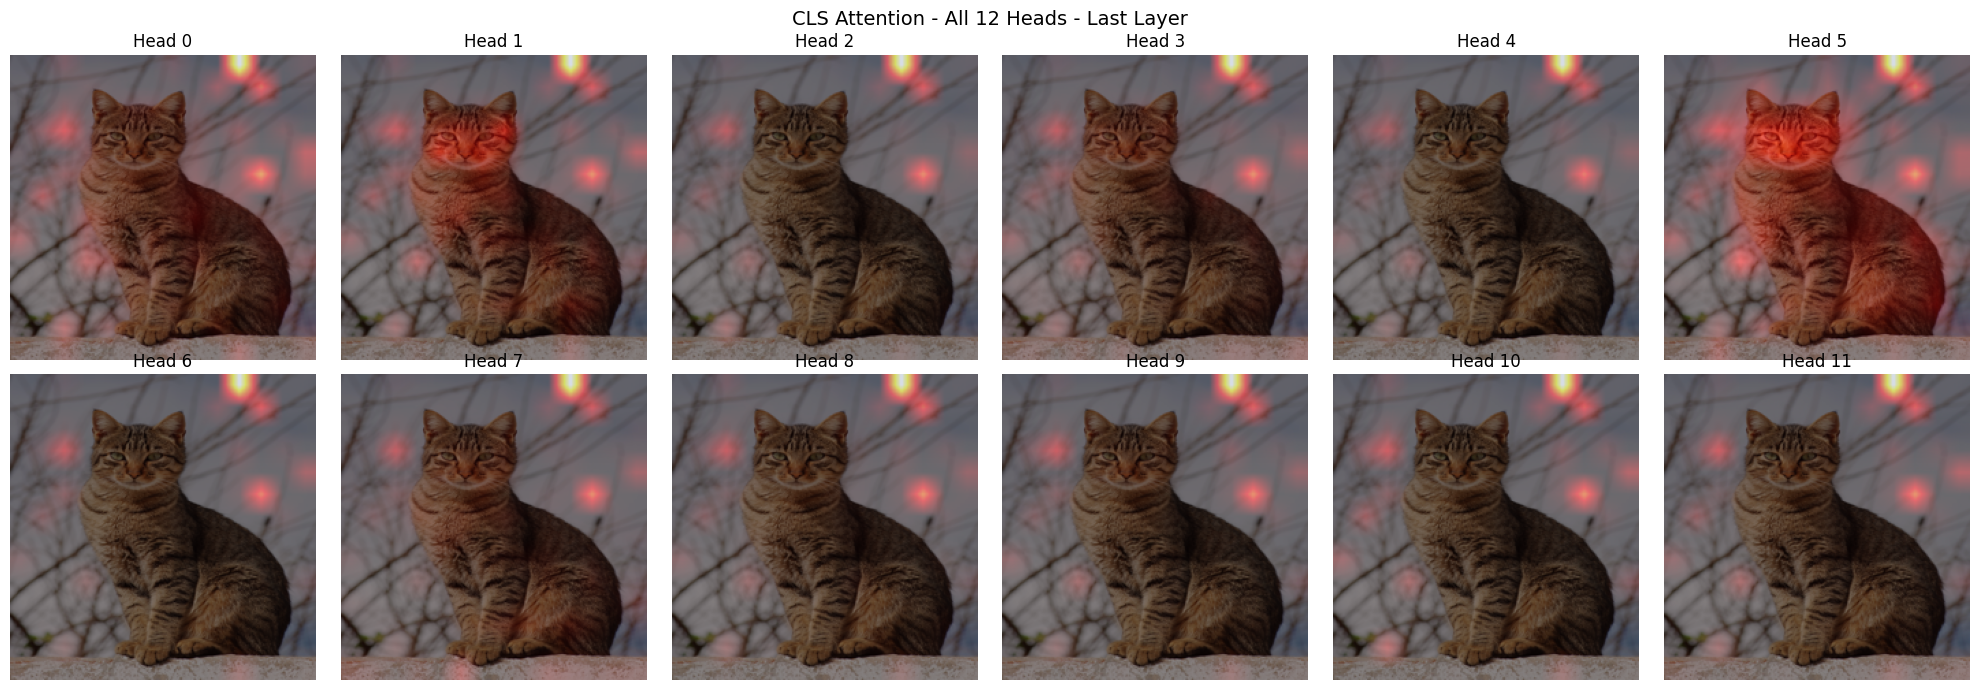

In [42]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for head_idx in range(12):
    cls_attn = attn_weights[0, head_idx, 0, 1:]
    cls_attn_map = cls_attn.reshape(14, 14).numpy()
    attn_resized = np.array(
        Image.fromarray(cls_attn_map).resize((224, 224),
                                              resample=Image.BILINEAR)
    )

    ax = axes[head_idx // 6][head_idx % 6]
    ax.imshow(img_display)
    ax.imshow(attn_resized, cmap='hot', alpha=0.5)
    ax.set_title(f'Head {head_idx}')
    ax.axis('off')

plt.suptitle('CLS Attention - All 12 Heads - Last Layer', fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
# [DATASET] Build CIFAR-10-LT at IF=100

import numpy as np
import torchvision
import torchvision.transforms as transforms

def build_cifar10_lt(if_factor, n_max=5000, seed=42):
    """
    Returns a subsampled CIFAR-10 dataset with long-tail distribution.

    if_factor : imbalance factor (IF). IF=1 means balanced.
    n_max     : samples kept for the most frequent class (class 0).
    seed      : for reproducibility of the random subsample.
    """

    C = 10  # number of classes

    # --- Step 1: compute target sample count per class ---
    # Formula: n(c) = n_max * IF^(-c / (C-1))
    # At c=0: n(0) = n_max * IF^0 = n_max         (most frequent)
    # At c=9: n(9) = n_max * IF^(-1)  = n_max/IF  (least frequent)
    class_counts = [
        int(n_max * (if_factor ** (-c / (C - 1))))
        for c in range(C)
    ]
    print("Target samples per class:")

    for c, count in enumerate(class_counts):
        print(f"  Class {c}: {count} samples")

    # --- Step 2: load full CIFAR-10 train split ---
    full_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True,
        transform=transforms.ToTensor()
    )

    targets = np.array(full_dataset.targets)  # shape [50000]

    # --- Step 3: subsample each class ---
    rng = np.random.default_rng(seed)
    selected_indices = []

    for c in range(C):
        class_indices = np.where(targets == c)[0]  # all indices for class c
        n_keep = class_counts[c]
        chosen = rng.choice(class_indices, size=n_keep, replace=False)
        selected_indices.extend(chosen.tolist())

    # --- Step 4: build a Subset ---
    subset = torch.utils.data.Subset(full_dataset, selected_indices)

    return subset, class_counts

# Run it
import torch
lt_dataset, class_counts = build_cifar10_lt(if_factor=100)

print(f"\nTotal samples in LT dataset: {len(lt_dataset)}")
print(f"Majority class (class 0): {class_counts[0]} samples")
print(f"Minority class (class 9): {class_counts[-1]} samples")

Target samples per class:
  Class 0: 5000 samples
  Class 1: 2997 samples
  Class 2: 1796 samples
  Class 3: 1077 samples
  Class 4: 645 samples
  Class 5: 387 samples
  Class 6: 232 samples
  Class 7: 139 samples
  Class 8: 83 samples
  Class 9: 50 samples

Total samples in LT dataset: 12406
Majority class (class 0): 5000 samples
Minority class (class 9): 50 samples


In [44]:
# [IMAGES] Pull one image from majority class (0) and minority class (9)

def find_first_of_class(dataset, target_class):
    """
    Walks through a dataset and returns the first sample
    whose label matches target_class.
    Returns: (image_tensor, label, index_in_dataset)
    """
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        if label == target_class:
            return img, label, idx
    raise ValueError(f"Class {target_class} not found in dataset")

# Find one majority and one minority image
img_majority, label_majority, idx_majority = find_first_of_class(lt_dataset, target_class=0)
img_minority, label_minority, idx_minority = find_first_of_class(lt_dataset, target_class=9)

print(f"Majority image: class={label_majority}, index={idx_majority}, shape={img_majority.shape}")
print(f"Minority image: class={label_minority}, index={idx_minority}, shape={img_minority.shape}")

Majority image: class=0, index=0, shape=torch.Size([3, 32, 32])
Minority image: class=9, index=12356, shape=torch.Size([3, 32, 32])


In [45]:
# [EXTRACT] Preprocess and extract attention weights for both images

import torch
import torchvision.transforms as T

# --- Step 1: define preprocessing pipeline ---
# ViT-B/16 was pretrained on ImageNet at 224x224
# Mean and std are ImageNet statistics — using wrong values
# shifts the input distribution the model was calibrated for
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# --- Step 2: safe hook registration ---
# Remove old hook if it exists — prevents silent stacking
try:
    hook.remove()
    print("Old hook removed.")
except:
    print("No existing hook to remove.")

attention_store = {}  # fresh store

def hook_attention(module, input, output):
    B, N, C = input[0].shape
    qkv = module.qkv(input[0])
    qkv = qkv.reshape(B, N, 3,
                      module.num_heads,
                      C // module.num_heads)
    qkv = qkv.permute(2, 0, 3, 1, 4)
    q, k, v = qkv.unbind(0)
    scale = (C // module.num_heads) ** -0.5
    attn = (q @ k.transpose(-2, -1)) * scale
    attn = attn.softmax(dim=-1)
    attention_store['current'] = attn.detach()

hook = model.blocks[-1].attn.register_forward_hook(hook_attention)
print("Fresh hook registered.")

# --- Step 3: forward pass for majority image ---
model.eval()
with torch.no_grad():
    # Add batch dimension: [3,32,32] -> [1,3,32,32]
    input_majority = preprocess(img_majority).unsqueeze(0)
    _ = model(input_majority)
    # Save immediately — next forward pass will overwrite 'current'
    attn_majority = attention_store['current'].clone()  # [1, 12, 197, 197]

# --- Step 4: forward pass for minority image ---
with torch.no_grad():
    input_minority = preprocess(img_minority).unsqueeze(0)
    _ = model(input_minority)
    attn_minority = attention_store['current'].clone()  # [1, 12, 197, 197]

print(f"Majority attention shape: {attn_majority.shape}")
print(f"Minority attention shape: {attn_minority.shape}")

# Quick sanity check: rows should sum to 1.0 (softmax output)
print(f"Majority attn row sum (head 0, token 0): {attn_majority[0, 0, 0, :].sum().item():.4f}")
print(f"Minority attn row sum (head 0, token 0): {attn_minority[0, 0, 0, :].sum().item():.4f}")

Old hook removed.
Fresh hook registered.
Majority attention shape: torch.Size([1, 12, 197, 197])
Minority attention shape: torch.Size([1, 12, 197, 197])
Majority attn row sum (head 0, token 0): 1.0000
Minority attn row sum (head 0, token 0): 1.0000


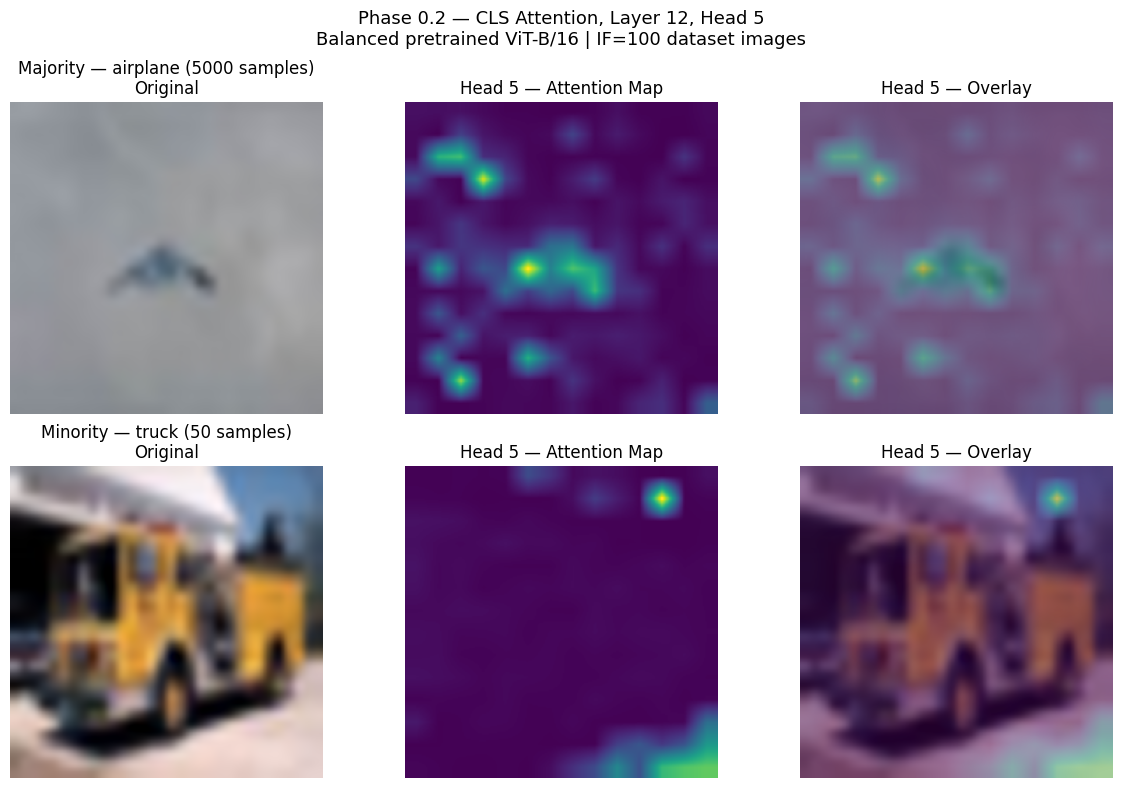

Saved.


In [46]:
# [PLOT] Side-by-side attention maps: majority vs minority class

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch.nn.functional as F

def extract_cls_attention_map(attn_tensor, head_idx):
    """
    Extracts CLS-to-patch attention for one head and reshapes to 14x14.

    attn_tensor : shape [1, num_heads, 197, 197]
    head_idx    : which head to extract (0-indexed)

    Returns: [14, 14] numpy array, values in [0, 1]
    """
    # CLS token is row 0. Columns 1-196 are the 196 patch tokens.
    cls_attn = attn_tensor[0, head_idx, 0, 1:]   # shape [196]

    # Reshape flat 196 -> spatial 14x14
    cls_attn = cls_attn.reshape(14, 14)           # shape [14, 14]

    # Upsample to 224x224 for overlay on the image
    # unsqueeze twice: need [batch, channel, H, W] for interpolate
    cls_attn = cls_attn.unsqueeze(0).unsqueeze(0) # [1, 1, 14, 14]
    cls_attn = F.interpolate(
        cls_attn,
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    )
    cls_attn = cls_attn.squeeze().numpy()         # back to [224, 224]
    return cls_attn

def prepare_image_for_display(img_tensor):
    """
    Converts a preprocessed tensor back to displayable [224, 224, 3] numpy array.
    Reverses the ImageNet normalization so colours look natural.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.squeeze(0)   # remove batch dim: [3, 224, 224]
    img = img * std + mean        # reverse normalization
    img = img.clamp(0, 1)         # clip to valid range
    img = img.permute(1, 2, 0)    # channel-last for matplotlib: [224, 224, 3]
    return img.numpy()

# --- choose head to inspect ---
HEAD = 5

# --- extract maps ---
map_majority = extract_cls_attention_map(attn_majority, HEAD)
map_minority = extract_cls_attention_map(attn_minority, HEAD)

# --- prepare display images ---
img_maj_display = prepare_image_for_display(input_majority)
img_min_display = prepare_image_for_display(input_minority)

# --- CIFAR-10 class names for readable titles ---
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# --- plot ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, (img_display, attn_map, label) in enumerate([
    (img_maj_display, map_majority, label_majority),
    (img_min_display, map_minority, label_minority)
]):
    class_freq = class_counts[label]
    title_prefix = f"{'Majority' if row==0 else 'Minority'} — {class_names[label]} ({class_freq} samples)"

    # Column 0: original image
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"{title_prefix}\nOriginal")
    axes[row, 0].axis('off')

    # Column 1: attention map only
    axes[row, 1].imshow(attn_map, cmap='viridis')
    axes[row, 1].set_title(f"Head {HEAD} — Attention Map")
    axes[row, 1].axis('off')

    # Column 2: overlay
    axes[row, 2].imshow(img_display)
    axes[row, 2].imshow(attn_map, cmap='viridis', alpha=0.5)
    axes[row, 2].set_title(f"Head {HEAD} — Overlay")
    axes[row, 2].axis('off')

plt.suptitle(f"Phase 0.2 — CLS Attention, Layer 12, Head {HEAD}\nBalanced pretrained ViT-B/16 | IF=100 dataset images",
             fontsize=13)
plt.tight_layout()
plt.savefig(f'phase02_head{HEAD}_majority_vs_minority.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [47]:
# ── Section 1: Imports and constants ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 has 10 classes, 5000 training images per class when balanced
C = 10
n_max = 5000   # majority class keeps all its samples
IF = 100       # imbalance factor

# CIFAR-10 class names, in index order
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [48]:
# ── Section 2: Compute n(c) for each class ────────────────────────────────────
class_indices = np.arange(C)   # [0, 1, 2, ..., 9]

# Apply the long-tailed formula
n_per_class = np.array([
    int(n_max * (IF ** (-c / (C - 1))))
    for c in class_indices
])

print("Samples per class:")
for i, (name, n) in enumerate(zip(class_names, n_per_class)):
    print(f"  Class {i} ({name:>12s}): {n:>5d} samples")

print(f"\nTotal training samples: {n_per_class.sum()}")
print(f"Majority / minority ratio: {n_per_class[0]} / {n_per_class[-1]} = {n_per_class[0]/n_per_class[-1]:.1f}x")

Samples per class:
  Class 0 (    airplane):  5000 samples
  Class 1 (  automobile):  2997 samples
  Class 2 (        bird):  1796 samples
  Class 3 (         cat):  1077 samples
  Class 4 (        deer):   645 samples
  Class 5 (         dog):   387 samples
  Class 6 (        frog):   232 samples
  Class 7 (       horse):   139 samples
  Class 8 (        ship):    83 samples
  Class 9 (       truck):    50 samples

Total training samples: 12406
Majority / minority ratio: 5000 / 50 = 100.0x


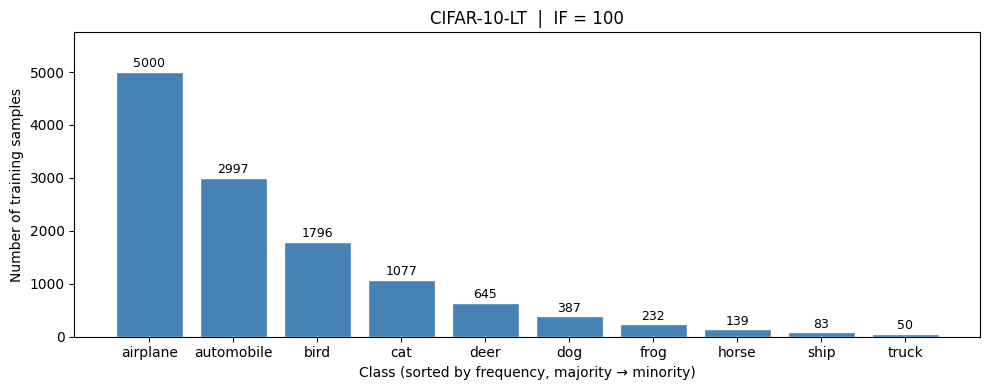

Saved: cifar10lt_sample_dist.png


In [49]:
# ── Section 3: Bar chart of samples per class ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(class_names, n_per_class, color="steelblue", edgecolor="white")

# Annotate each bar with its count
for bar, n in zip(bars, n_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(n), ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Class (sorted by frequency, majority → minority)")
ax.set_ylabel("Number of training samples")
ax.set_title("CIFAR-10-LT  |  IF = 100")
ax.set_ylim(0, n_max * 1.15)

plt.tight_layout()
plt.savefig("cifar10lt_sample_dist.png", dpi=150)
plt.show()
print("Saved: cifar10lt_sample_dist.png")

In [50]:
# ── Section 4: Compute f(c) and log f(c) ──────────────────────────────────────
total_samples = n_per_class.sum()

f_c = n_per_class / total_samples          # relative frequency, sums to 1
log_f_c = np.log(f_c)                      # natural log

print("\nClass frequencies and log frequencies:")
print(f"{'Class':<5} {'Name':<12} {'n(c)':>6}  {'f(c)':>8}  {'log f(c)':>10}")
print("-" * 50)
for i, (name, n, f, lf) in enumerate(zip(class_names, n_per_class, f_c, log_f_c)):
    print(f"  {i:<3}  {name:<12} {n:>6}  {f:>8.4f}  {lf:>10.4f}")


Class frequencies and log frequencies:
Class Name           n(c)      f(c)    log f(c)
--------------------------------------------------
  0    airplane       5000    0.4030     -0.9087
  1    automobile     2997    0.2416     -1.4206
  2    bird           1796    0.1448     -1.9326
  3    cat            1077    0.0868     -2.4440
  4    deer            645    0.0520     -2.9567
  5    dog             387    0.0312     -3.4675
  6    frog            232    0.0187     -3.9792
  7    horse           139    0.0112     -4.4915
  8    ship             83    0.0067     -5.0071
  9    truck            50    0.0040     -5.5139


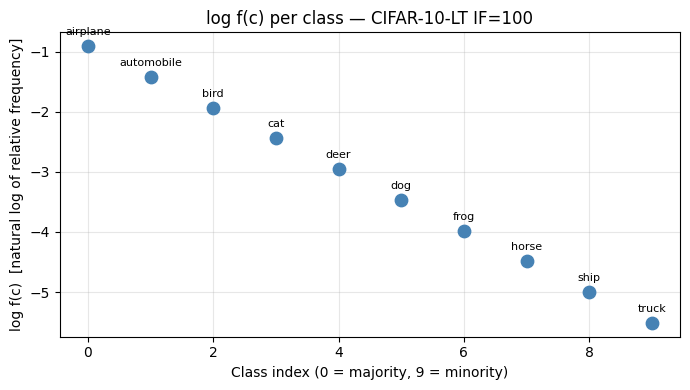

Saved: cifar10lt_log_fc.png


In [51]:
# ── Section 5: Scatter log f(c) vs class index ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(class_indices, log_f_c, s=80, color="steelblue", zorder=3)

for i, name in enumerate(class_names):
    ax.annotate(name, (i, log_f_c[i]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

ax.set_xlabel("Class index (0 = majority, 9 = minority)")
ax.set_ylabel("log f(c)  [natural log of relative frequency]")
ax.set_title("log f(c) per class — CIFAR-10-LT IF=100")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cifar10lt_log_fc.png", dpi=150)
plt.show()
print("Saved: cifar10lt_log_fc.png")